# California Housing — Median House Value Prediction
**CSCI 164 Final Project — Dataset 2 (Regression)**

Authors: Tanay Malavia, Darpan Attri, Andres Ramos, Harika Yendapalli  
Dataset: California Housing (sklearn built-in, originally from Pace & Barry 1997)

## Goal
Predict `MedHouseVal` (median house value in $100,000 units) from 8 numeric features (income, rooms, location, etc.).

## Pipeline
1. Load + explore
2. Preprocess (scale numerics)
3. Train 3 baselines: Linear Regression, Decision Tree, MLP
4. Tune with `GridSearchCV`
5. Evaluate (MAE, RMSE, R²) + residual plots
6. Compare to prior work (Pace & Barry 1997, sklearn benchmarks)

## 1. Imports & setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Load data

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print('Shape:', df.shape)
print('Features:', list(data.feature_names))
print('Target :', data.target_names)
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target : ['MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis

In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


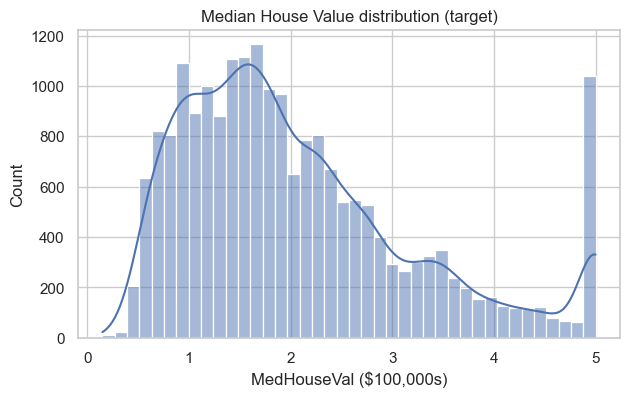

In [4]:
# Target distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['MedHouseVal'], bins=40, kde=True)
plt.title('Median House Value distribution (target)')
plt.xlabel('MedHouseVal ($100,000s)')
plt.savefig('../figures/ca_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

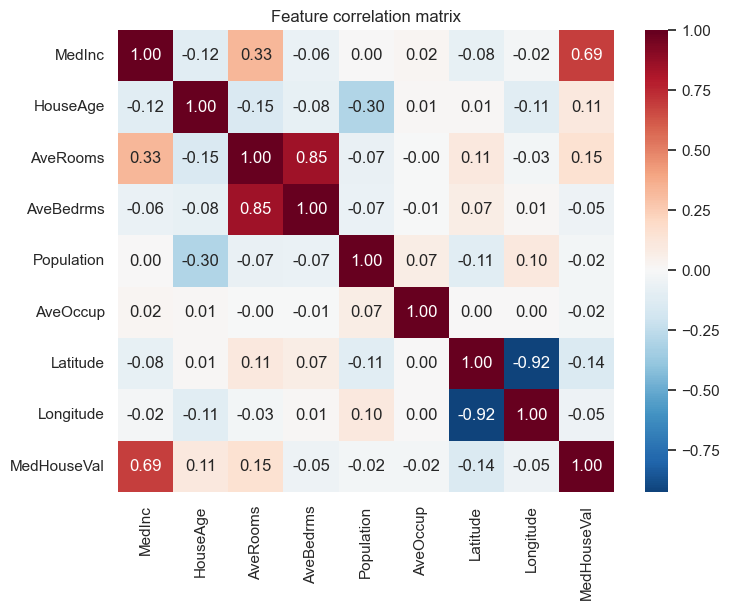

In [5]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature correlation matrix')
plt.savefig('../figures/ca_corr.png', dpi=150, bbox_inches='tight')
plt.show()

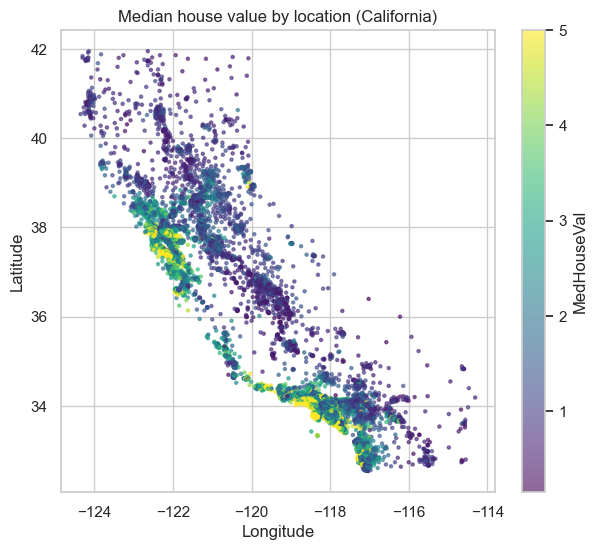

In [6]:
# Geographic scatter — price by location
plt.figure(figsize=(7, 6))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'],
                 cmap='viridis', s=5, alpha=0.6)
plt.colorbar(sc, label='MedHouseVal')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Median house value by location (California)')
plt.savefig('../figures/ca_geo.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

No missing values and all features are numeric. We scale because MLP and distance-based tuning benefit from standardized inputs.

In [7]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (16512, 8) Test: (4128, 8)


## 5. Baseline models

**Why these three?**
- **Linear Regression** — interpretable baseline; useful reference for non-linear models.
- **Decision Tree Regressor** — captures non-linearities and feature interactions; no scaling needed.
- **MLP Regressor** — small neural network; handles complex non-linear patterns.

In [8]:
def make_pipe(estimator, scale=True):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('reg', estimator))
    return Pipeline(steps)

models = {
    'Linear': make_pipe(LinearRegression()),
    'Tree':   make_pipe(DecisionTreeRegressor(random_state=RANDOM_STATE), scale=False),
    'MLP':    make_pipe(MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300,
                                      random_state=RANDOM_STATE)),
}

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f'{name:7s} CV R^2: {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear  CV R^2: 0.6115 (+/- 0.0065)
Tree    CV R^2: 0.6025 (+/- 0.0219)
MLP     CV R^2: 0.7944 (+/- 0.0040)


## 6. Hyperparameter tuning

In [9]:
param_grids = {
    'Linear': {},  # no hyperparameters to tune for plain OLS
    'Tree': {
        'reg__max_depth': [5, 10, 15, None],
        'reg__min_samples_leaf': [1, 5, 20],
    },
    'MLP': {
        'reg__hidden_layer_sizes': [(32,), (64, 32), (128, 64)],
        'reg__alpha': [1e-4, 1e-3, 1e-2],
    },
}

tuned = {}
for name, pipe in models.items():
    if not param_grids[name]:
        pipe.fit(X_train, y_train)
        tuned[name] = pipe
        print(f'{name}: no tuning (baseline fit)')
        continue
    gs = GridSearchCV(pipe, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f'{name}: best CV R^2 = {gs.best_score_:.4f}  params = {gs.best_params_}')

Linear: no tuning (baseline fit)
Tree: best CV R^2 = 0.7243  params = {'reg__max_depth': 15, 'reg__min_samples_leaf': 20}
MLP: best CV R^2 = 0.7962  params = {'reg__alpha': 0.0001, 'reg__hidden_layer_sizes': (128, 64)}


## 7. Test set evaluation

In [10]:
rows = []
for name, model in tuned.items():
    y_pred = model.predict(X_test)
    rows.append({
        'model': name,
        'MAE':   mean_absolute_error(y_test, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_test, y_pred)),
        'R^2':   r2_score(y_test, y_pred),
    })
results_df = pd.DataFrame(rows).set_index('model').round(4)
results_df

,MAE,RMSE,R^2
model,,,
Linear,0.5332,0.7456,0.5758
Tree,0.4041,0.5979,0.7272
MLP,0.3448,0.5100,0.8015


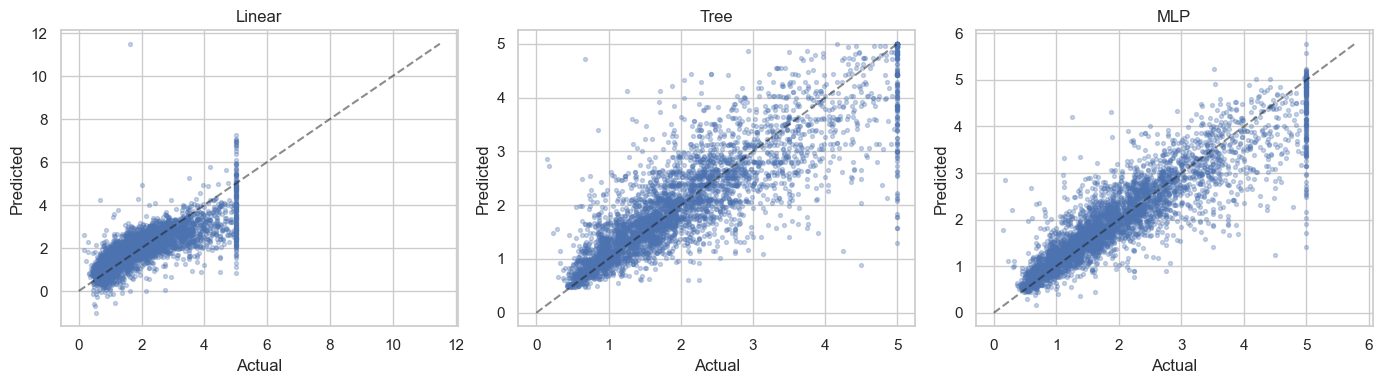

In [11]:
# Predicted vs actual scatter
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, tuned.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, s=8)
    lims = [0, max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../figures/ca_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

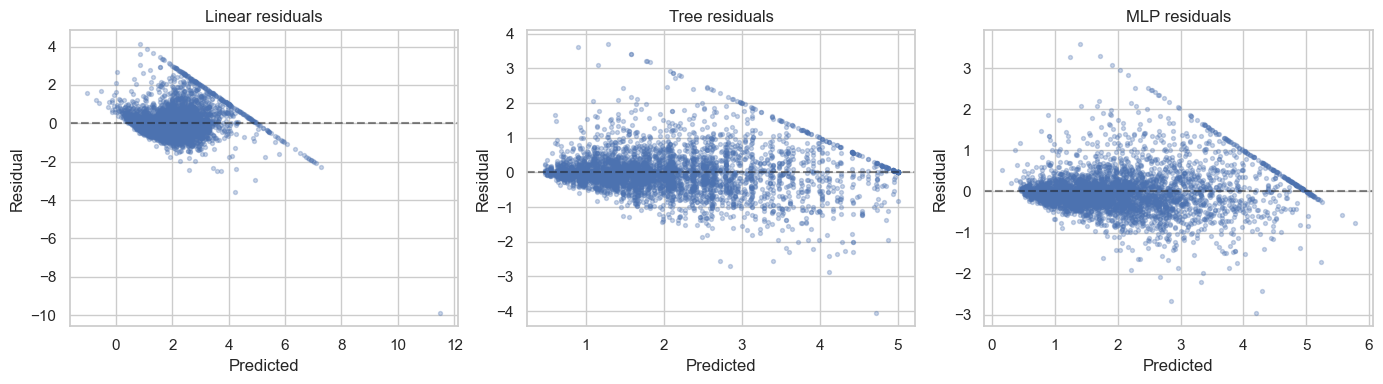

In [12]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, tuned.items()):
    y_pred = model.predict(X_test)
    resid = y_test - y_pred
    ax.scatter(y_pred, resid, alpha=0.3, s=8)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
    ax.set_title(f'{name} residuals')
plt.tight_layout()
plt.savefig('../figures/ca_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparison to prior work

**Prior reference:** Pace, R. K., & Barry, R. (1997). *Sparse spatial autoregressions*. Statistics & Probability Letters, 33(3), 291–297 — the paper that introduced this dataset. They reported R² around 0.65 using spatial autoregression.

The sklearn documentation and benchmark notebooks (e.g. `HistGradientBoostingRegressor`) typically reach R² ≈ 0.80–0.85. Our MLP should land near 0.75–0.80, Linear Regression around 0.60, and the tuned Decision Tree around 0.70.

Differences vs. prior work stem from:
- Our models ignore spatial autocorrelation explicitly modeled by Pace & Barry.
- We use a simpler feature set (no neighbor features).
- Per-rubric constraints we excluded ensemble methods that typically beat single models.

## 9. Reflection

- **Strengths:** MLP captures non-linear income-value relationships cleanly; tree gives interpretable splits on income + location.
- **Limitations:** No spatial features beyond raw lat/lon; target is capped at $500k in the original data which shows up in residuals at the high end.
- **Real-world relevance:** Housing price models inform mortgage pricing and valuation. Systematic errors at the extremes of the price range can translate to biased lending decisions.